In [3]:
!pip install pyqt5

  Using cached PyQt5-5.15.11-cp38-abi3-win_amd64.whl (6.9 MB)
  Using cached PyQt5_Qt5-5.15.2-py3-none-win_amd64.whl (50.1 MB)


In [6]:
import os
import sys
import json

from PIL import Image

from PyQt5.QtCore import Qt, QRect, QPoint
from PyQt5.QtGui import QPixmap, QPainter, QPen
from PyQt5.QtWidgets import (
    QApplication, QMainWindow, QWidget, QLabel, QPushButton, QFileDialog,
    QVBoxLayout, QHBoxLayout, QSlider, QCheckBox, QMessageBox
)


# ---------- Виджет изображения с выделением области ----------
class CropImageLabel(QLabel):
    def __init__(self):
        super().__init__()
        self.setAlignment(Qt.AlignCenter)
        self.setMinimumSize(700, 500)
        self.setStyleSheet("QLabel { background-color: #222; color: #ccc; }")

        self.original_pixmap = None       # исходный pixmap (оригинальный размер)
        self.display_pixmap = None        # масштабированный под QLabel pixmap
        self.display_rect = QRect()       # область, где реально нарисован display_pixmap внутри QLabel

        self.selecting = False
        self.start_point = QPoint()
        self.end_point = QPoint()
        self.selection_rect_widget = QRect()  # прямоугольник выделения в координатах QLabel

        # crop в координатах исходного изображения: (x, y, w, h) или None
        self.crop_rect_image = None

    def set_image(self, image_path):
        pixmap = QPixmap(image_path)
        if pixmap.isNull():
            self.original_pixmap = None
            self.display_pixmap = None
            self.display_rect = QRect()
            self.setText("Не удалось загрузить изображение")
            return

        self.original_pixmap = pixmap
        self._update_scaled_pixmap()
        self.update()

    def resizeEvent(self, event):
        super().resizeEvent(event)
        self._update_scaled_pixmap()
        self.update()

    def _update_scaled_pixmap(self):
        if not self.original_pixmap:
            return

        scaled = self.original_pixmap.scaled(
            self.size(),
            Qt.KeepAspectRatio,
            Qt.SmoothTransformation
        )
        self.display_pixmap = scaled

        x = (self.width() - scaled.width()) // 2
        y = (self.height() - scaled.height()) // 2
        self.display_rect = QRect(x, y, scaled.width(), scaled.height())

    def clear_crop(self):
        self.crop_rect_image = None
        self.selection_rect_widget = QRect()
        self.update()

    def set_crop_from_image_rect(self, crop_rect_image):
        """Установить выделение из координат исходного изображения (x,y,w,h)"""
        self.crop_rect_image = crop_rect_image
        self.selection_rect_widget = QRect()

        if not crop_rect_image or not self.original_pixmap or self.display_rect.isNull():
            self.update()
            return

        ix, iy, iw, ih = crop_rect_image
        ow = self.original_pixmap.width()
        oh = self.original_pixmap.height()

        if ow <= 0 or oh <= 0:
            self.update()
            return

        sx = self.display_rect.width() / ow
        sy = self.display_rect.height() / oh

        x = int(self.display_rect.x() + ix * sx)
        y = int(self.display_rect.y() + iy * sy)
        w = int(iw * sx)
        h = int(ih * sy)

        self.selection_rect_widget = QRect(x, y, w, h).normalized()
        self.update()

    def paintEvent(self, event):
        super().paintEvent(event)
        painter = QPainter(self)

        # Рисуем картинку вручную (чтобы контролировать display_rect)
        if self.display_pixmap and not self.display_rect.isNull():
            painter.drawPixmap(self.display_rect, self.display_pixmap)

        # Рисуем рамку выделения
        rect = self.selection_rect_widget.normalized()
        if not rect.isNull() and rect.width() > 1 and rect.height() > 1:
            pen = QPen(Qt.red, 2, Qt.SolidLine)
            painter.setPen(pen)
            painter.drawRect(rect)

    def mousePressEvent(self, event):
        if event.button() == Qt.LeftButton and self._point_in_image(event.pos()):
            self.selecting = True
            self.start_point = event.pos()
            self.end_point = event.pos()
            self.selection_rect_widget = QRect(self.start_point, self.end_point).normalized()
            self.update()
        super().mousePressEvent(event)

    def mouseMoveEvent(self, event):
        if self.selecting:
            self.end_point = event.pos()
            rect = QRect(self.start_point, self.end_point).normalized()
            rect = rect.intersected(self.display_rect)  # не выходить за границы изображения
            self.selection_rect_widget = rect
            self.update()
        super().mouseMoveEvent(event)

    def mouseReleaseEvent(self, event):
        if self.selecting and event.button() == Qt.LeftButton:
            self.selecting = False
            rect = self.selection_rect_widget.normalized()

            if rect.width() > 2 and rect.height() > 2:
                self.crop_rect_image = self._widget_rect_to_image_rect(rect)
            else:
                self.crop_rect_image = None
                self.selection_rect_widget = QRect()

            self.update()
        super().mouseReleaseEvent(event)

    def _point_in_image(self, p):
        return self.display_rect.contains(p)

    def _widget_rect_to_image_rect(self, wrect):
        if not self.original_pixmap or self.display_rect.isNull():
            return None

        ow = self.original_pixmap.width()
        oh = self.original_pixmap.height()

        # Перевод из координат QLabel (display_rect) в исходное изображение
        x1 = max(wrect.left(), self.display_rect.left())
        y1 = max(wrect.top(), self.display_rect.top())
        x2 = min(wrect.right(), self.display_rect.right())
        y2 = min(wrect.bottom(), self.display_rect.bottom())

        if x2 <= x1 or y2 <= y1:
            return None

        rx1 = (x1 - self.display_rect.x()) / self.display_rect.width()
        ry1 = (y1 - self.display_rect.y()) / self.display_rect.height()
        rx2 = (x2 - self.display_rect.x()) / self.display_rect.width()
        ry2 = (y2 - self.display_rect.y()) / self.display_rect.height()

        ix1 = int(round(rx1 * ow))
        iy1 = int(round(ry1 * oh))
        ix2 = int(round(rx2 * ow))
        iy2 = int(round(ry2 * oh))

        ix1 = max(0, min(ix1, ow - 1))
        iy1 = max(0, min(iy1, oh - 1))
        ix2 = max(ix1 + 1, min(ix2, ow))
        iy2 = max(iy1 + 1, min(iy2, oh))

        return (ix1, iy1, ix2 - ix1, iy2 - iy1)


class DatasetLabeler(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Разметка датасета (PyQt5)")
        self.resize(1200, 750)

        self.dataset_dir = None
        self.output_dir = None
        self.image_files = []
        self.current_index = -1
        self.is_loading_ui = False

        self._build_ui()

    def _build_ui(self):
        central = QWidget()
        self.setCentralWidget(central)

        main_layout = QVBoxLayout(central)

        # Верх
        top_layout = QHBoxLayout()
        self.btn_open = QPushButton("Открыть датасет")
        self.btn_open.clicked.connect(self.open_dataset)

        self.btn_clear_crop = QPushButton("Сбросить обрезку")
        self.btn_clear_crop.clicked.connect(self.clear_crop)

        self.lbl_info = QLabel("Папка не выбрана")

        top_layout.addWidget(self.btn_open)
        top_layout.addWidget(self.btn_clear_crop)
        top_layout.addWidget(self.lbl_info, 1)
        main_layout.addLayout(top_layout)

        # Центр: изображение + справа разметка
        content_layout = QHBoxLayout()

        self.image_label = CropImageLabel()
        content_layout.addWidget(self.image_label, 3)

        right_panel = QVBoxLayout()
        self.humanity_title = QLabel("Человечность: 0.50")
        self.humanity_slider = QSlider(Qt.Horizontal)
        self.humanity_slider.setRange(0, 100)
        self.humanity_slider.setValue(50)
        self.humanity_slider.valueChanged.connect(self.on_humanity_changed)

        self.chk_hair = QCheckBox("Наличие волос")
        self.chk_glasses = QCheckBox("Наличие очков")

        right_panel.addWidget(self.humanity_title)
        right_panel.addWidget(self.humanity_slider)
        right_panel.addSpacing(20)
        right_panel.addWidget(self.chk_hair)
        right_panel.addWidget(self.chk_glasses)
        right_panel.addStretch(1)

        content_layout.addLayout(right_panel, 1)
        main_layout.addLayout(content_layout)

        # Низ: навигация
        nav_layout = QHBoxLayout()
        self.btn_prev = QPushButton("Предыдущее (←)")
        self.btn_next = QPushButton("Следующее (→)")
        self.btn_prev.clicked.connect(self.prev_image)
        self.btn_next.clicked.connect(self.next_image)

        self.lbl_counter = QLabel("0 / 0")
        self.lbl_counter.setAlignment(Qt.AlignCenter)

        nav_layout.addWidget(self.btn_prev)
        nav_layout.addWidget(self.lbl_counter, 1)
        nav_layout.addWidget(self.btn_next)
        main_layout.addLayout(nav_layout)

        self._update_nav_buttons()

    # ---------- Горячие клавиши ----------
    def keyPressEvent(self, event):
        if event.key() == Qt.Key_Left:
            self.prev_image()
            return
        if event.key() == Qt.Key_Right:
            self.next_image()
            return
        super().keyPressEvent(event)

    # ---------- Dataset ----------
    def open_dataset(self):
        folder = QFileDialog.getExistingDirectory(self, "Выберите папку с изображениями")
        if not folder:
            return

        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        files = [
            f for f in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, f)) and os.path.splitext(f.lower())[1] in exts
        ]
        files.sort()

        if not files:
            QMessageBox.warning(self, "Ошибка", "В выбранной папке нет изображений.")
            return

        self.dataset_dir = folder
        parent = os.path.dirname(folder)
        base = os.path.basename(folder.rstrip("/\\"))
        self.output_dir = os.path.join(parent, f"{base}_labeled")
        os.makedirs(self.output_dir, exist_ok=True)

        self.image_files = files
        self.current_index = 0

        self.lbl_info.setText(f"Датасет: {self.dataset_dir}  |  Выход: {self.output_dir}")
        self.load_current_image()
        self._update_nav_buttons()

    def load_current_image(self):
        if not self.image_files or not (0 <= self.current_index < len(self.image_files)):
            return

        filename = self.image_files[self.current_index]
        img_path = os.path.join(self.dataset_dir, filename)

        self.image_label.set_image(img_path)

        data = self._read_annotation(filename)

        self.is_loading_ui = True
        humanity = float(data.get("humanity", 0.5))
        hair = float(data.get("hair", 0.0))
        glasses = float(data.get("glasses", 0.0))
        crop = data.get("crop", None)

        self.humanity_slider.setValue(int(round(humanity * 100)))
        self.humanity_title.setText(f"Человечность: {humanity:.2f}")
        self.chk_hair.setChecked(hair >= 0.5)
        self.chk_glasses.setChecked(glasses >= 0.5)

        if isinstance(crop, dict):
            try:
                cx = int(crop.get("x", 0))
                cy = int(crop.get("y", 0))
                cw = int(crop.get("w", 0))
                ch = int(crop.get("h", 0))
                if cw > 0 and ch > 0:
                    self.image_label.set_crop_from_image_rect((cx, cy, cw, ch))
                else:
                    self.image_label.clear_crop()
            except Exception:
                self.image_label.clear_crop()
        else:
            self.image_label.clear_crop()

        self.is_loading_ui = False

        self._update_counter()
        self._update_nav_buttons()

    def clear_crop(self):
        self.image_label.clear_crop()

    # ---------- Аннотации и сохранение ----------
    def _json_name_for_image(self, image_filename):
        # JSON тоже по "итоговому" jpg-имени
        base_name = os.path.splitext(image_filename)[0]
        return f"{base_name}.json"

    def _jpg_name_for_image(self, image_filename):
        base_name = os.path.splitext(image_filename)[0]
        return f"{base_name}.jpg"

    def _annotation_path(self, image_filename):
        return os.path.join(self.output_dir, self._json_name_for_image(image_filename))

    def _output_jpg_path(self, image_filename):
        return os.path.join(self.output_dir, self._jpg_name_for_image(image_filename))

    def _read_annotation(self, image_filename):
        ann_path = self._annotation_path(image_filename)
        if os.path.exists(ann_path):
            try:
                with open(ann_path, "r", encoding="utf-8") as f:
                    return json.load(f)
            except Exception:
                pass
        return {"humanity": 0.5, "hair": 0.0, "glasses": 0.0}

    def save_current_annotation(self):
        if not self.image_files or self.current_index < 0:
            return

        filename = self.image_files[self.current_index]
        src_img_path = os.path.join(self.dataset_dir, filename)
        dst_jpg_path = self._output_jpg_path(filename)
        ann_path = self._annotation_path(filename)

        # 1) Открыть исходник и применить crop
        try:
            with Image.open(src_img_path) as img:
                img = img.convert("RGB")  # гарантируем JPG-совместимость

                crop = self.image_label.crop_rect_image
                if crop is not None:
                    x, y, w, h = crop
                    x = max(0, x)
                    y = max(0, y)
                    w = max(1, w)
                    h = max(1, h)
                    x2 = min(img.width, x + w)
                    y2 = min(img.height, y + h)
                    if x2 > x and y2 > y:
                        img = img.crop((x, y, x2, y2))

                # 2) Сохранить всегда как JPG
                img.save(dst_jpg_path, "JPEG", quality=95)
        except Exception as e:
            QMessageBox.warning(self, "Ошибка сохранения изображения", f"{filename}\n{e}")
            return

        # 3) Сохранить JSON
        crop_data = None
        if self.image_label.crop_rect_image is not None:
            x, y, w, h = self.image_label.crop_rect_image
            crop_data = {"x": int(x), "y": int(y), "w": int(w), "h": int(h)}

        data = {
            "humanity": round(self.humanity_slider.value() / 100.0, 4),
            "hair": 1.0 if self.chk_hair.isChecked() else 0.0,
            "glasses": 1.0 if self.chk_glasses.isChecked() else 0.0
        }
        if crop_data is not None:
            data["crop"] = crop_data

        try:
            with open(ann_path, "w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
        except Exception as e:
            QMessageBox.warning(self, "Ошибка сохранения JSON", f"{filename}\n{e}")

    # ---------- Навигация ----------
    def prev_image(self):
        if not self.image_files or self.current_index <= 0:
            return
        self.save_current_annotation()  # автосохранение при перелистывании
        self.current_index -= 1
        self.load_current_image()

    def next_image(self):
        if not self.image_files or self.current_index >= len(self.image_files) - 1:
            return
        self.save_current_annotation()  # автосохранение при перелистывании
        self.current_index += 1
        self.load_current_image()

    def closeEvent(self, event):
        self.save_current_annotation()
        event.accept()

    # ---------- UI ----------
    def on_humanity_changed(self, value):
        if self.is_loading_ui:
            return
        self.humanity_title.setText(f"Человечность: {value / 100.0:.2f}")

    def _update_counter(self):
        if not self.image_files:
            self.lbl_counter.setText("0 / 0")
        else:
            self.lbl_counter.setText(f"{self.current_index + 1} / {len(self.image_files)}")

    def _update_nav_buttons(self):
        has_data = bool(self.image_files)
        self.btn_prev.setEnabled(has_data and self.current_index > 0)
        self.btn_next.setEnabled(has_data and self.current_index < len(self.image_files) - 1)


def main():
    app = QApplication(sys.argv)
    w = DatasetLabeler()
    w.show()
    sys.exit(app.exec_())


if __name__ == "__main__":
    main()

SystemExit: 0

In [1]:
import torch

In [2]:
import torch.nn as nn
from torchvision.models import resnet18

In [3]:
images_size = (256, 256)


In [4]:
class HumanityModel(nn.Module):
    def __init__(self):
        super().__init__()
        w, h = (images_size[0] // 2 // 2 // 2, images_size[1] // 2 // 2 // 2)
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Flatten(),
            nn.Linear(64 * w * h, 100),
            nn.Dropout(0.2),
            nn.Linear(100, 50),
            nn.Linear(50, 10),
            nn.Dropout(0.2),
            nn.Linear(10, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [4]:
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights
class HumanityModel(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT

        self.model = resnet18(weights=weights)
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512,1)
        )
    def forward(self, x):
        return self.model(x)

In [5]:
from pathlib import Path
from PIL import Image
import os
from torch.utils.data import Dataset
from torchvision import transforms
import json

class HumanityDataset(Dataset):

    def __init__(self):

        self.samples = []

        for fi in os.listdir("./humanity_train_labeled"):
            if fi.split(".")[-1] == "json":
                continue
            f = open(os.path.join("./humanity_train_labeled", fi.split(".")[0] + ".json"), "r")
            jdata = json.load(f)
            f.close()
            self.samples.append((os.path.join("./humanity_train_labeled", fi), jdata))
            
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")
        
        image = self.transform(image)
        label = torch.tensor([
            # label['humanity'],  # индекс 0
            # label['hair'],      # индекс 1
            label['glasses']    # индекс 2
        ], dtype=torch.float32)
        return image, label

In [6]:
from torch.utils.data import Dataset, DataLoader, random_split
dataset = HumanityDataset()
dataset[0]
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # Для воспроизводимости
)

In [7]:
from torch.utils.data import DataLoader

loader = DataLoader(

    train_dataset,

    batch_size=10,

    shuffle=True,

    num_workers=0

)
loaderv = DataLoader(

    val_dataset,

    batch_size=10,

    shuffle=False,

    num_workers=0

)

In [8]:
device = "cuda"
model = HumanityModel().to(device)

In [9]:
import torch
num_epochs = 30
learning_rate = 0.001
weight_decay = 0.01
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [13]:
for i in range(num_epochs):
    model.train()
    tl = 0.0
    for image, label in loader:
        image = image.to(device)
        label = label.to(device)
        
        outputs = model(image)
        loss = criterion(
            outputs,
            label.float()
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        tl += loss.item()
        model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in loaderv:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    val_loss /= len(loaderv)

    print(f"Epoch: {i}, loss: {round(tl / len(loader), 100)}, vloss: {round(val_loss, 100)}")

Epoch: 0, loss: 0.800639699612345, vloss: 0.6003642231225967
Epoch: 1, loss: 0.6446092128753662, vloss: 0.5391355231404305
Epoch: 2, loss: 0.5442869024617332, vloss: 0.45480456203222275
Epoch: 3, loss: 0.349461813058172, vloss: 0.3366652801632881
Epoch: 4, loss: 0.38404031310762676, vloss: 0.32885844446718693
Epoch: 5, loss: 0.14682293937416294, vloss: 0.7824323131007986
Epoch: 6, loss: 0.4915561479592725, vloss: 0.10492756636813283
Epoch: 7, loss: 0.1290647221196975, vloss: 0.08577661449089646
Epoch: 8, loss: 0.0825088888855784, vloss: 0.08733796142041683
Epoch: 9, loss: 0.0775269626748403, vloss: 0.029036759326118045
Epoch: 10, loss: 0.051614025042259266, vloss: 0.032651465793605894
Epoch: 11, loss: 0.05810802025670065, vloss: 0.006639744262344038
Epoch: 12, loss: 0.0690130143725217, vloss: 0.07543565795640461
Epoch: 13, loss: 0.08033982105293294, vloss: 0.018954849860165268
Epoch: 14, loss: 0.07307507307268679, vloss: 0.08218025579117239
Epoch: 15, loss: 0.049659163740995736, vloss:

In [14]:
model.eval()

HumanityModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
import matplotlib.pyplot as plt
import torch
import cv2
# Переводим модель в режим оценки


# Создаем сетку изображений
# fig, axes = plt.subplots(5, 10, figsize=(20, 10))  # 5 строк, 10 столбцов
# axes = axes.flatten()
vid = cv2.VideoCapture(0)
while True:
    ret, image = vid.read()
    if not ret:
        continue
    
    # Загружаем и трансформируем
    
    image_tensor = dataset.transform(Image.fromarray(image)).unsqueeze(0)  # Добавляем batch dimension
    image_tensor = image_tensor.to(device)
    # Предсказание
    with torch.no_grad():
        out = model(image_tensor)[0]  # Убираем batch dimension
        out = torch.sigmoid(out)
    print(f' Gl:{out[0]:.8f}')
    # Отображаем
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("👋 Завершение работы...")
        break
    cv2.imshow("hello", image)
vid.release()
cv2.destroyAllWindows()

#     axes[idx].axis('off')
#     axes[idx].set_title(
#         f'H:{out[0]:.2f} Hair:{out[1]:.2f} Gl:{out[2]:.2f}',
#         fontsize=8
#     )

# plt.tight_layout()
# plt.show()


IndexError: index 50 is out of bounds for axis 0 with size 50

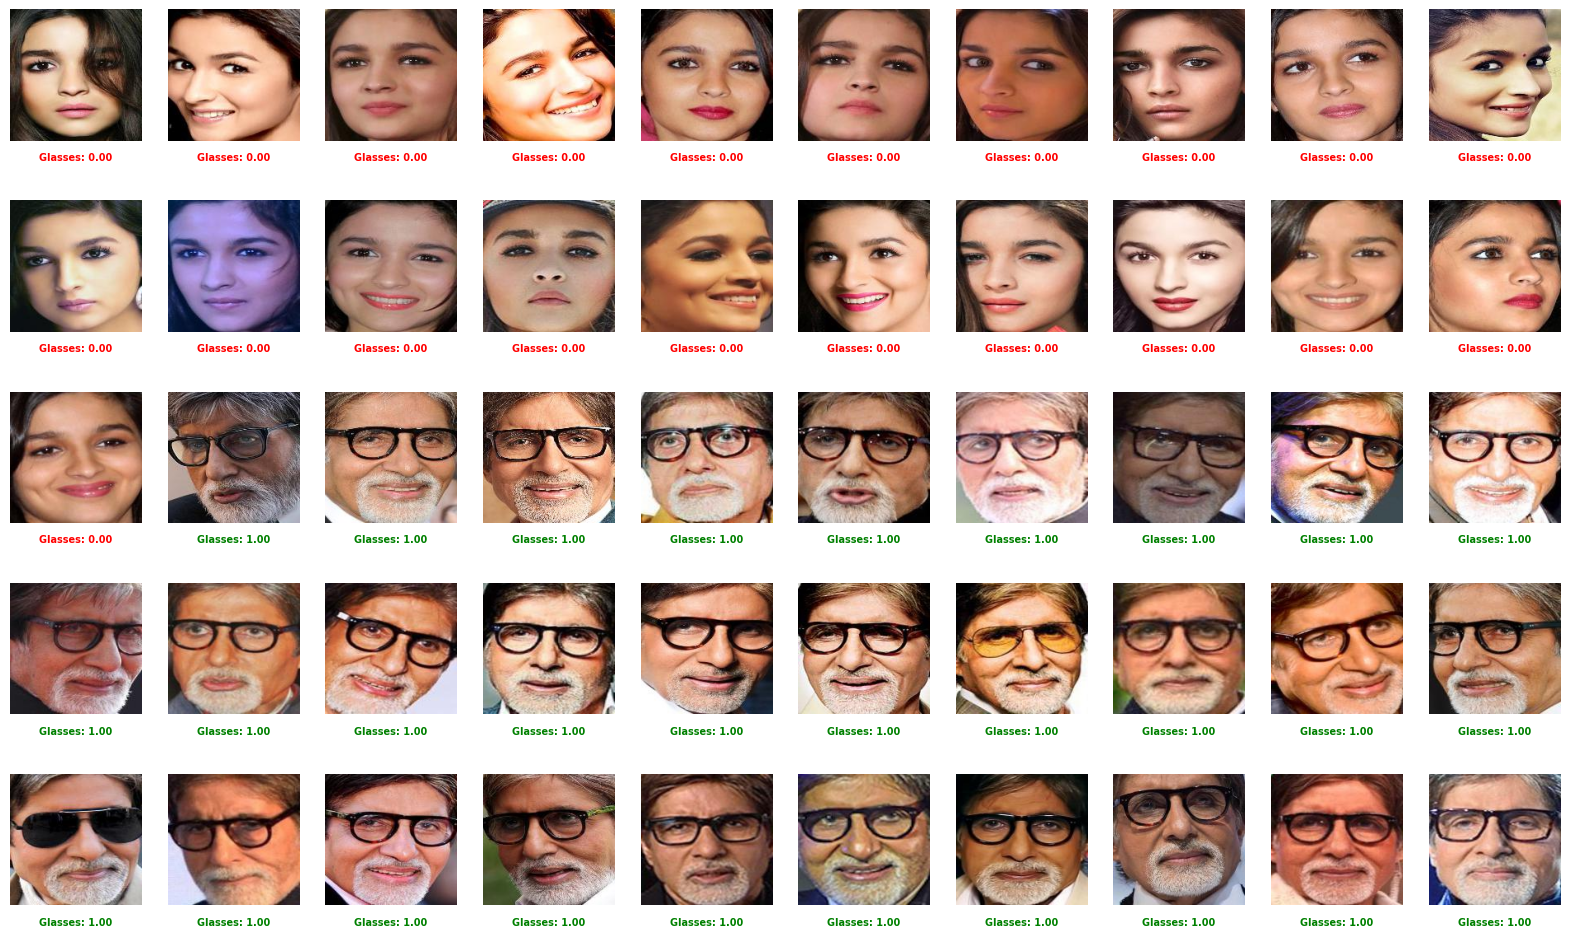

In [19]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()
device = next(model.parameters()).device

files = os.listdir("./resnet_train")[200:500]

fig, axes = plt.subplots(5, 10, figsize=(20, 12))
axes = axes.flatten()

for idx, fi in enumerate(files):
    image = Image.open(os.path.join("./resnet_train", fi)).convert("RGB")
    image_tensor = dataset.transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(image_tensor)
        out = torch.sigmoid(out)[0].cpu().numpy()
    # Цвета для значений
    def get_color(val):
        if val > 0.7: return 'green'
        elif val > 0.3: return 'orange'
        else: return 'red'
    
    axes[idx].imshow(image)
    axes[idx].axis('off')
    
    # Текст с цветовой индикацией
    labels = ['Glasses']
    colors = [get_color(out[i]) for i in range(1)]
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        axes[idx].text(
            0.5, -0.15 - i*0.1, 
            f'{label}: {out[i]:.2f}',
            transform=axes[idx].transAxes,
            ha='center',
            color=color,
            fontsize=7,
            fontweight='bold'
        )

plt.subplots_adjust(bottom=0.2)
plt.show()

In [21]:
import torch

# Переводим модель в режим оценки
model.eval()

# Создаем пример входных данных (batch_size=1, channels=1, height=256, width=256)
dummy_input = torch.randn(1, 3, 256, 256).to(device)

# Экспортируем в ONNX
onnx_path = "humanity_model.onnx"
torch.onnx.export(
    model,                          # Модель
    dummy_input,                    # Пример входа
    onnx_path,                      # Путь для сохранения
    export_params=True,             # Сохранить веса модели
    opset_version=11,               # Версия ONNX opset (11 или 12 хорошо поддерживаются)
    do_constant_folding=True,       # Оптимизация: предвычисление констант
    input_names=['input'],          # Имя входного слоя
    output_names=['output'],        # Имя выходного слоя
    dynamic_axes={                  # Динамические размеры (опционально)
        'input': {0: 'batch_size'},     # Переменный размер батча
        'output': {0: 'batch_size'}
    }
)

In [32]:
import cv2
import numpy as np
from PIL import Image
import onnxruntime as ort
from torchvision import transforms

# Загружаем ONNX модель
session = ort.InferenceSession("humanity_model.onnx")
input_name = session.get_inputs()[0].name

# Трансформации
transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
sigmoid = lambda x: 1 / (1 + np.exp(-x))
# Камера
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Подготовка входа
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(frame_rgb)
    image_tensor = transform(pil_image).unsqueeze(0).numpy()
    
    # Предсказание ONNX
    outputs = session.run(None, {input_name: image_tensor})[0][0]
    gl = outputs[0]
   
    
    # Отображение
    cv2.putText(frame, f"Gl:{sigmoid(gl):.6f}", 
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    cv2.imshow("ONNX Detection", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()